In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, accuracy_score, log_loss, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import shap

In [2]:
#x_data = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/x_data.csv')
x_data = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/feature_df_2.csv')
y_data = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/y_data_rms.csv')

In [19]:
x_df = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/feature_df_2.csv')

df = x_df.merge(y_data[['source_file', 'bottom_rms']], on='source_file').reset_index(drop=True)

df = df.dropna(subset=['bottom_rms'])

X = df.drop(columns=['source_file', 'bottom_rms'])
y = df['bottom_rms']

train_rem_idx = int(len(X) * 0.8) # 80% for training, 20% for validation and testing
val_test_idx = int(len(X) * 0.9) # 10% for validation, 10% for testing (from the remaining 20%)

X_train = X.iloc[:train_rem_idx]
X_val = X.iloc[train_rem_idx:val_test_idx]
X_test = X.iloc[val_test_idx:]

y_train = y.iloc[:train_rem_idx]
y_val = y.iloc[train_rem_idx:val_test_idx]
y_test = y.iloc[val_test_idx:]

In [20]:
def objective(trial):
    params = {
        "n_estimators": 5000,
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.05, log=True),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),

        "gamma": trial.suggest_float("gamma", 0, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),

        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "random_state": 42,
    }
    
    model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    return mse

import optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

[I 2026-06-06 14:25:40,551] A new study created in memory with name: no-name-233f314a-205a-489b-8293-47aa2a08972a
[I 2026-06-06 14:25:40,734] Trial 0 finished with value: 0.0005890257427850467 and parameters: {'max_depth': 8, 'learning_rate': 0.010463238748384302, 'subsample': 0.7287055179555694, 'colsample_bytree': 0.6718110370141253, 'min_child_weight': 14, 'gamma': 8.302878157199755, 'reg_alpha': 1.1020004864640666e-08, 'reg_lambda': 0.2592975462500241}. Best is trial 0 with value: 0.0005890257427850467.
[I 2026-06-06 14:25:40,862] Trial 1 finished with value: 0.0005890248771073912 and parameters: {'max_depth': 7, 'learning_rate': 0.0014033153378359775, 'subsample': 0.855271943539545, 'colsample_bytree': 0.9898254816256778, 'min_child_weight': 3, 'gamma': 4.323218518339722, 'reg_alpha': 0.00033263069651097064, 'reg_lambda': 9.61391643559562e-07}. Best is trial 1 with value: 0.0005890248771073912.
[I 2026-06-06 14:25:41,134] Trial 2 finished with value: 0.0005771682928033835 and para

In [33]:
#opt_params = {'n_estimators': 5000, 'max_depth': 10, 'learning_rate': 0.01525803171352834, 'subsample': 0.9361080329155063, 'colsample_bytree': 0.8774494819985844, 
#              'min_child_weight': 1, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', "random_state": 42}

opt_params = {'n_estimators': 5000, 'max_depth': 2, 'learning_rate': 0.015530627048745466, 'subsample': 0.7731651782531278, 'colsample_bytree': 0.7396227216381265, 'min_child_weight': 9, 'gamma': 0.024303918616681602, 'reg_alpha': 9.549875969413823e-05, 'reg_lambda': 4.166753511881032e-06}

final_model = xgb.XGBRegressor(**opt_params, early_stopping_rounds=70)
final_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)


from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_val)
y_pred_val = final_model.predict(X_val)
y_pred_test = final_model.predict(X_test)

print("Dummy R2:", r2_score(y_val, dummy.predict(X_val)))
print("Model R2 (val):", r2_score(y_val, y_pred_val))
print("Model R2 (test):", r2_score(y_test, y_pred_test))

print("Dummy MAE:", mean_absolute_error(y_val, dummy.predict(X_val)))
print("Model MAE (val):", mean_absolute_error(y_val, y_pred_val))
print("Model MAE (test):", mean_absolute_error(y_test, y_pred_test))

Dummy R2: -0.00012899893564211062
Model R2 (val): 0.1319457051247802
Model R2 (test): 0.20967933298947783
Dummy MAE: 0.018940237953174045
Model MAE (val): 0.0180752590761456
Model MAE (test): 0.018971396192133495


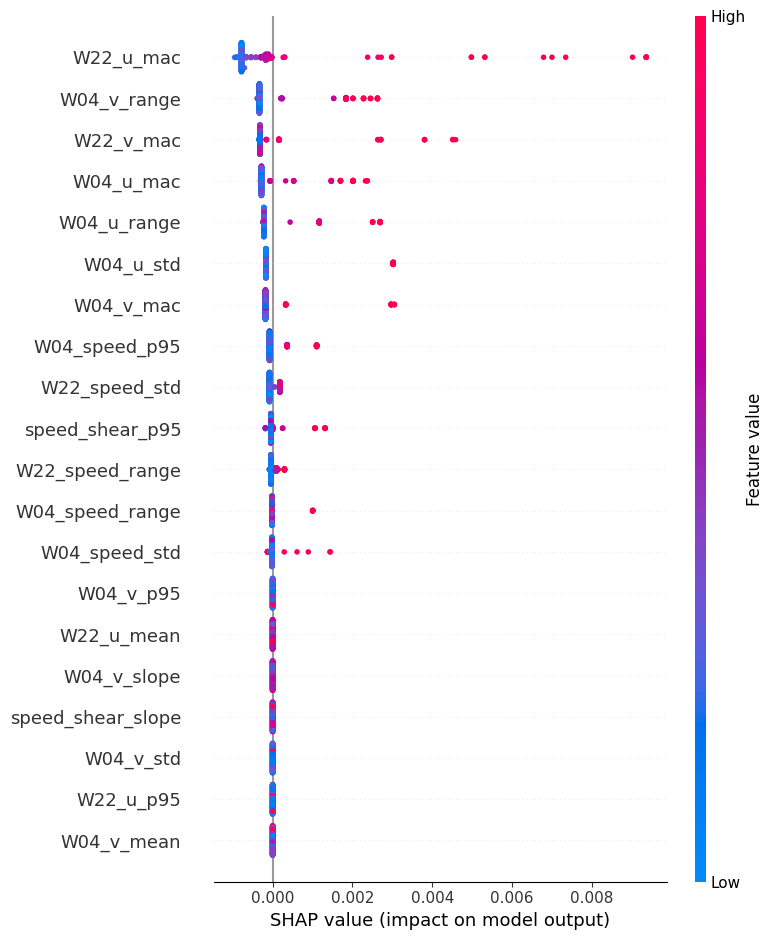

In [34]:
shap_values_final = shap.TreeExplainer(final_model).shap_values(X_val)
shap.summary_plot(shap_values_final, X_val, plot_type="dot")

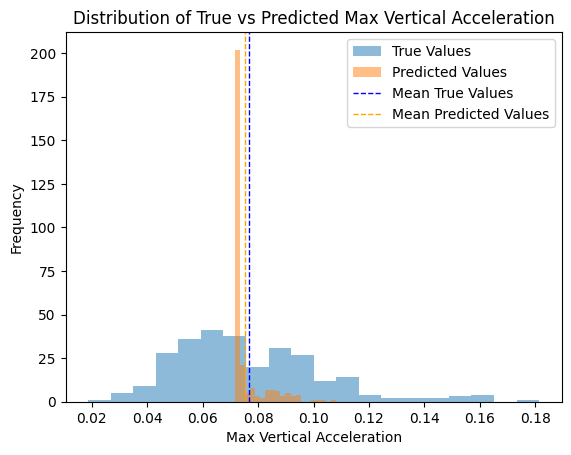

In [35]:
plt.hist(y_test, bins=20, alpha=0.5, label='True Values')
plt.hist(y_pred_test, bins=20, alpha=0.5, label='Predicted Values')
plt.xlabel('Max Vertical Acceleration')
plt.ylabel('Frequency')
plt.title('Distribution of True vs Predicted Max Vertical Acceleration')
plt.axvline(np.mean(y_test), color='blue', linestyle='dashed', linewidth=1, label='Mean True Values')
plt.axvline(np.mean(y_pred_test), color='orange', linestyle='dashed', linewidth=1, label='Mean Predicted Values')
plt.legend()
plt.show()

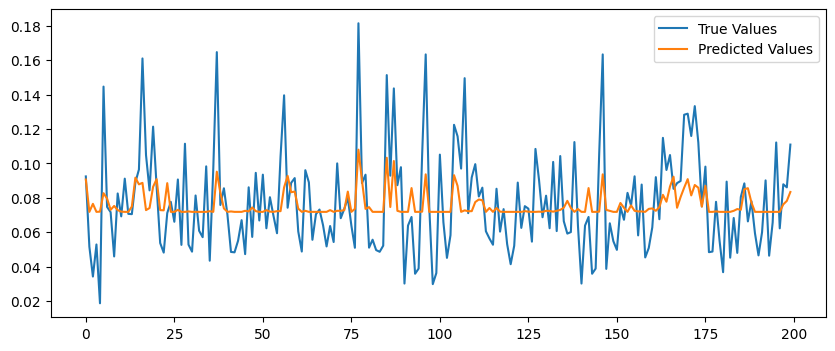

In [38]:
x_axis = np.arange(len(y_test))
plt.figure(figsize=(10,4))
plt.plot(x_axis[:200], y_test[:200], label='True Values')
plt.plot(x_axis[:200], y_pred_test[:200], label='Predicted Values')
plt.legend()
plt.show()